<a href="https://colab.research.google.com/github/Sakshi6360/Some-of-my-Machine-Learning-Works/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Titanic Survival prediction**

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [5]:
# For data manipulation and visualization
import numpy as np
import pandas as pd
# import data plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For predictive data analysis
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import sklearn.svm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve

In [6]:
tr = pd.read_csv(r"train.csv")#reading training dataset
te = pd.read_csv(r"test.csv")#reading test dataset

In [7]:
(tr.shape,te.shape)

((891, 12), (418, 11))

In [8]:
tr.info()#collecting information training dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
tr.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
te.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [11]:
te.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [12]:
tr.duplicated().sum()

np.int64(0)

In [13]:
te.duplicated().sum()

np.int64(0)

In [14]:
tr.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
te.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [16]:
def missing (tr):
    missing_no = tr.isnull().sum().sort_values()
    missing_percent = ((tr.isnull().sum()/tr.isnull().count())*100).sort_values(ascending=False)
    missing_values = pd.concat([missing_no, missing_percent], axis=1, keys=['missing_Number', 'missing_Percent'])
    return missing_values

In [17]:
missing(tr)

,missing_Number,missing_Percent
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000
Embarked,2,0.224467


In [18]:
missing(te)

,missing_Number,missing_Percent
PassengerId,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Embarked,0,0.000000
Fare,1,0.239234
Age,86,20.574163


In [19]:
#fill null values with mean,median ,mode
tr['Age']=tr['Age'].fillna(tr['Age'].mean())
tr['Embarked']=tr['Embarked'].fillna(tr['Embarked'].mode())
print(tr)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                             Allen, Mr. William Henry    male  35.000000   
..                                                 ...     ...        ...   
886 

In [20]:
#fill null values with mean,median ,mode
te['Age']=te['Age'].fillna(te['Age'].mean())
te['Embarked']=te['Embarked'].fillna(te['Embarked'].mode())
print(tr)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex        Age  \
0                              Braund, Mr. Owen Harris    male  22.000000   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000   
2                               Heikkinen, Miss. Laina  female  26.000000   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000   
4                             Allen, Mr. William Henry    male  35.000000   
..                                                 ...     ...        ...   
886 

In [21]:
sexDict = {'male': 0, 'female': 1}
tr.Sex = [sexDict[item] for item in tr.Sex]
tr.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


/tmp/ipykernel_1412/859159715.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corr.append(data[i])
/tmp/ipykernel_1412/859159715.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr, y=labels, palette='viridis')


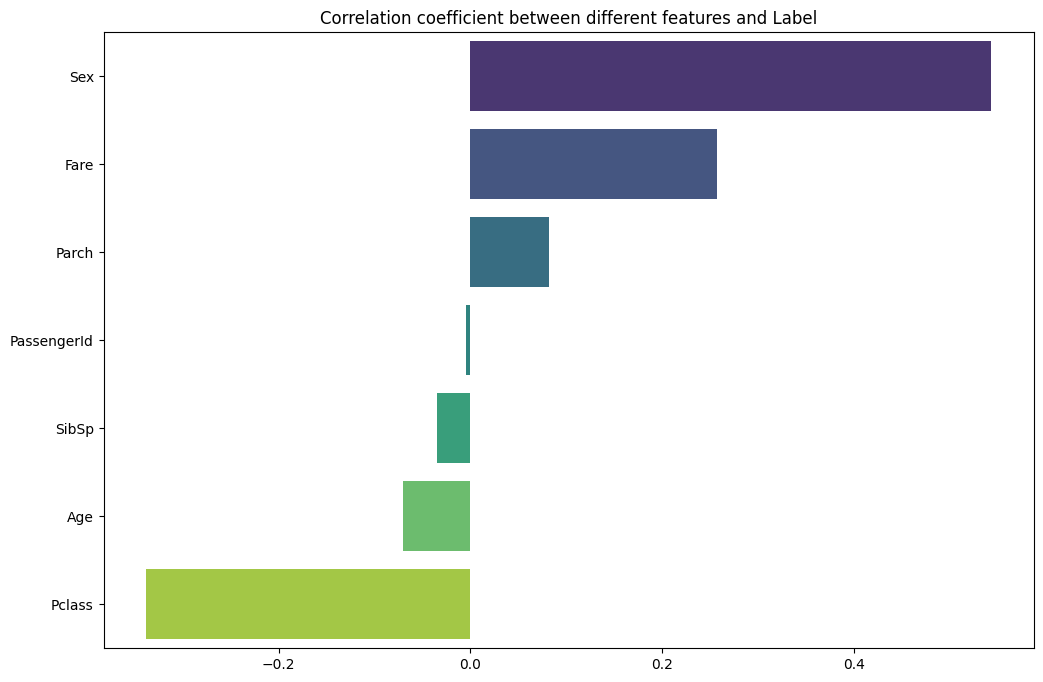

In [22]:
plt.figure(figsize=(12,8))
data = tr.select_dtypes(include=np.number).corr()["Survived"].sort_values(ascending=False)
indices = data.index
labels = []
corr = []
for i in range(1, len(indices)):
    labels.append(indices[i])
    corr.append(data[i])
sns.barplot(x=corr, y=labels, palette='viridis')
plt.title('Correlation coefficient between different features and Label')
plt.show()

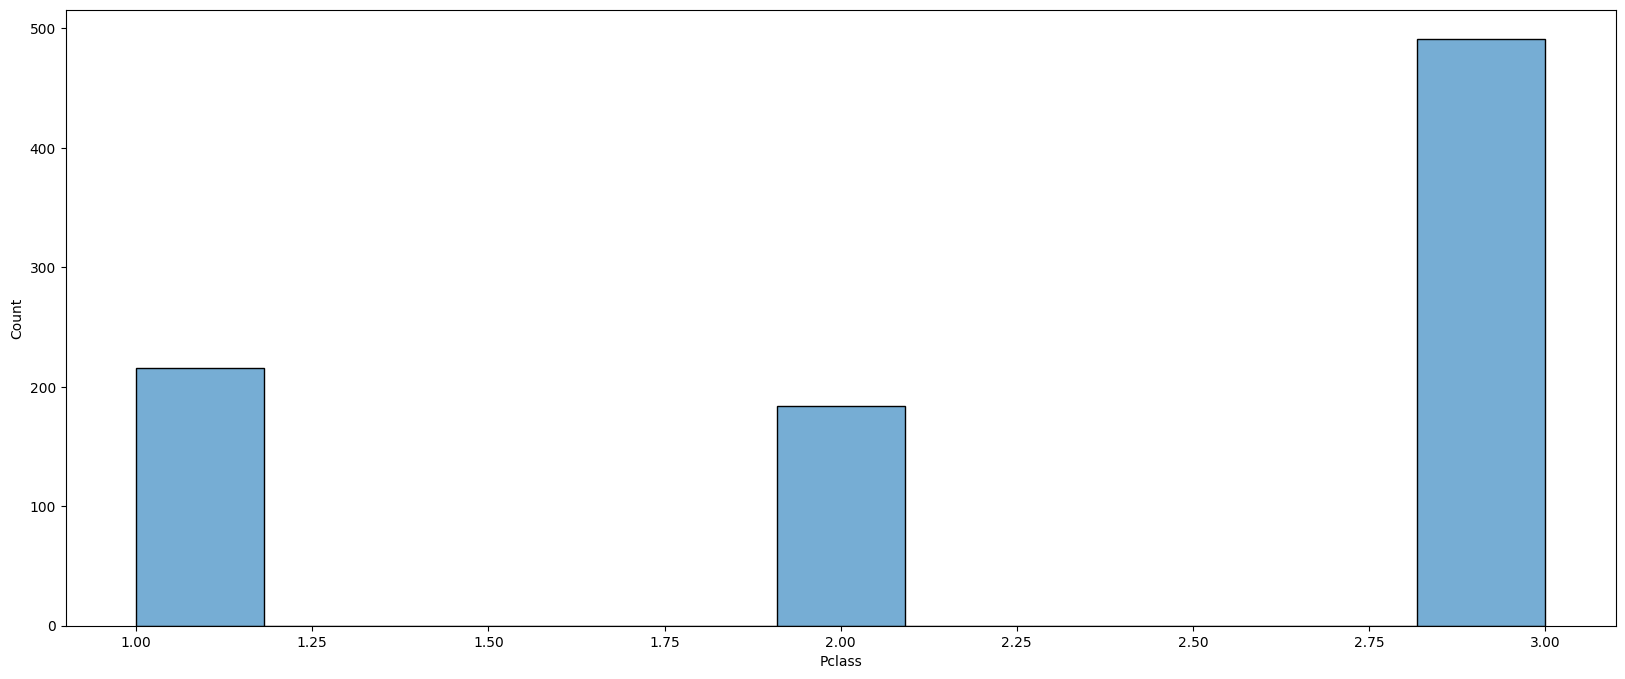

In [23]:
plt.figure(figsize=(20,8))
sns.histplot(tr.Pclass, color=sns.color_palette('Blues_d')[2])
plt.show()

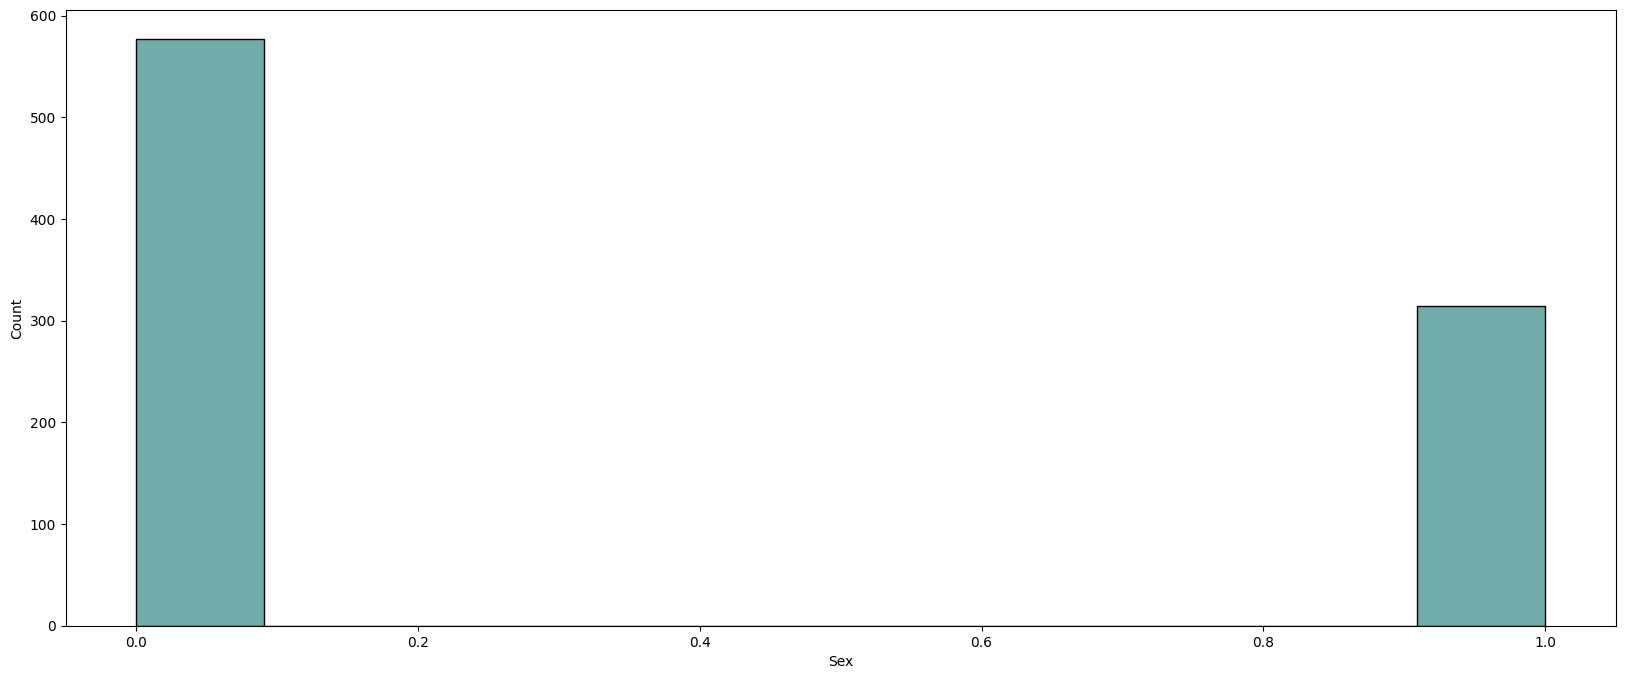

In [24]:
plt.figure(figsize=(20,8))
sns.histplot(tr.Sex, color=sns.color_palette('crest')[2])
plt.show()

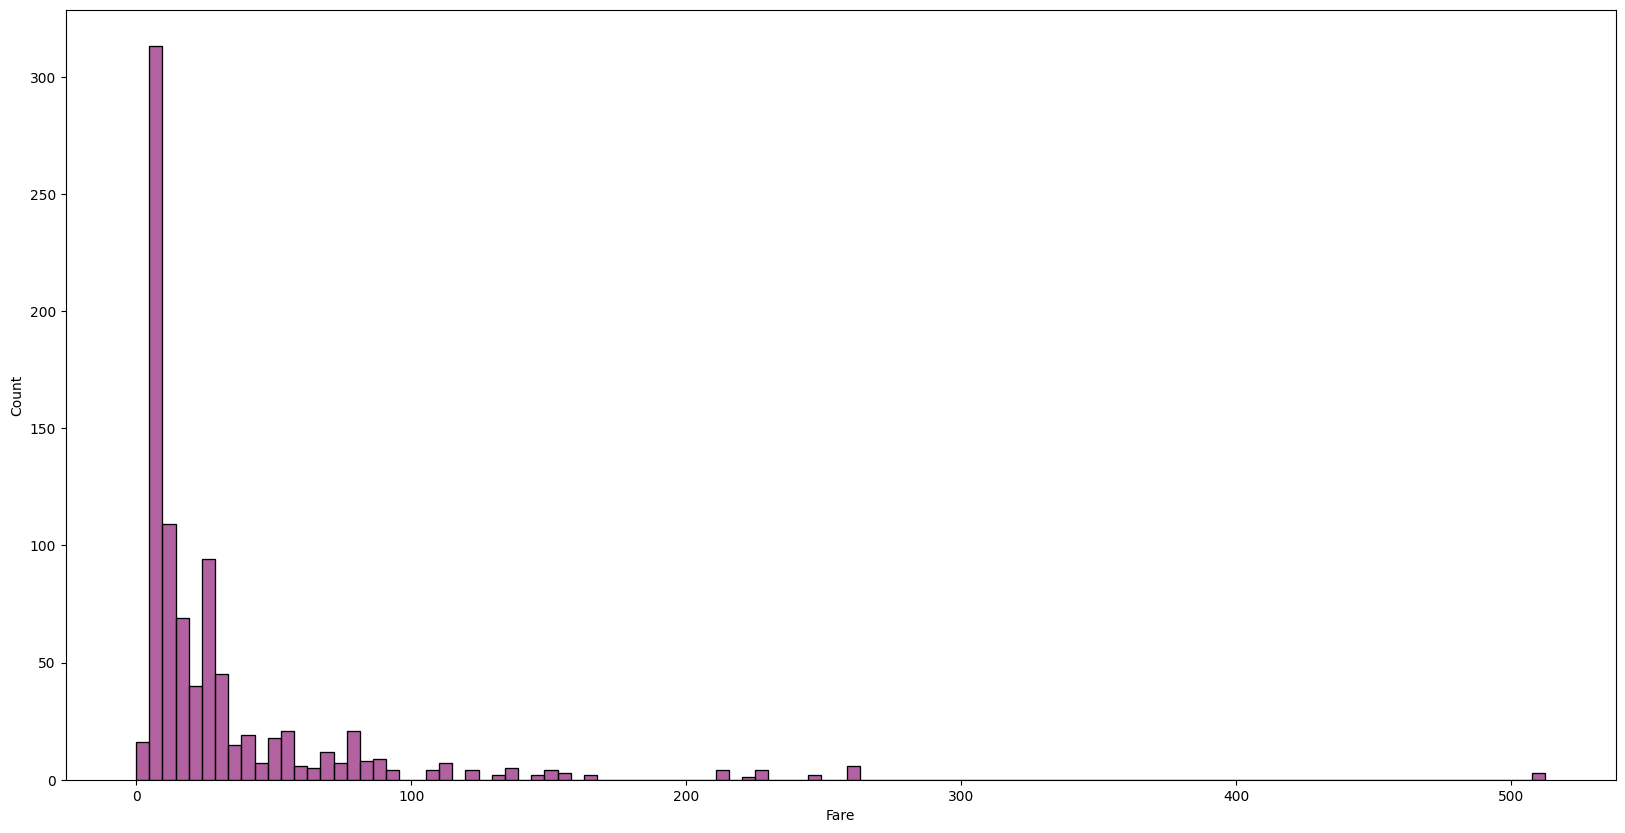

In [25]:
plt.figure(figsize=(20,10))
sns.histplot(tr.Fare, color=sns.color_palette('magma')[2])
plt.show()


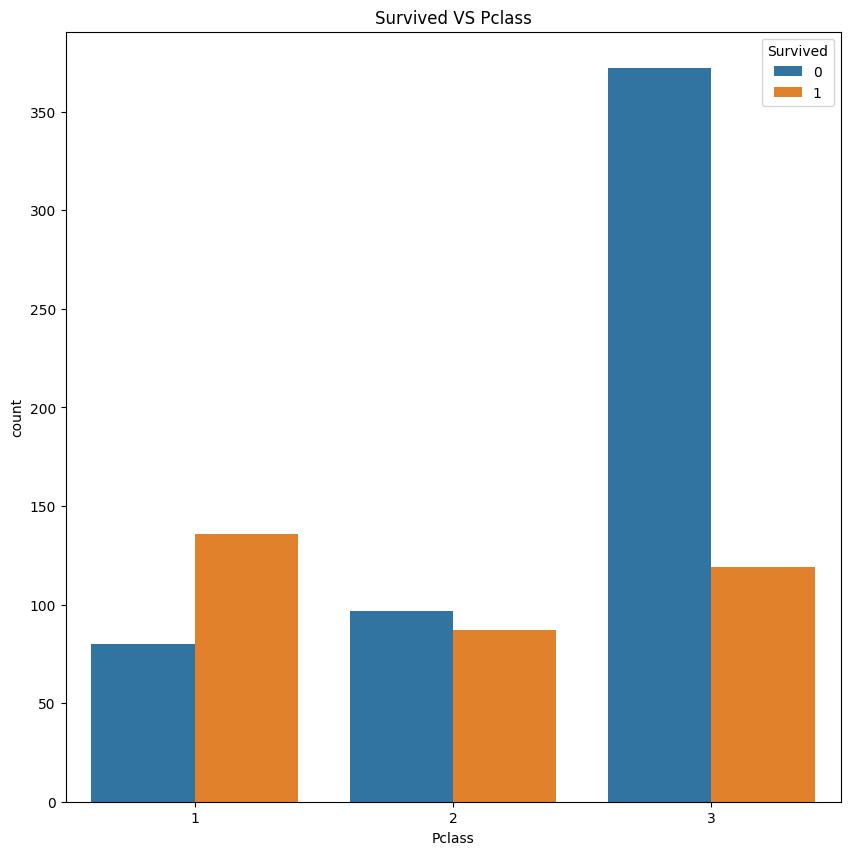

In [26]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "Pclass", hue = "Survived", data = tr)
plt.title("Survived VS Pclass")
plt.show()

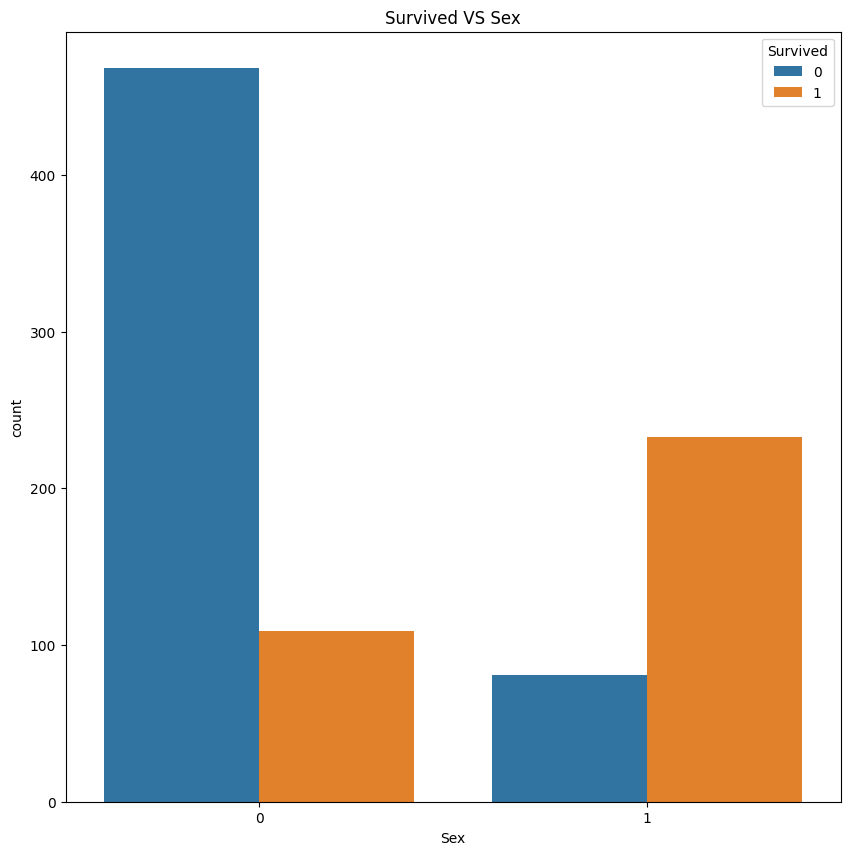

In [27]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "Sex", hue = "Survived", data = tr)
plt.title("Survived VS Sex")
plt.show()

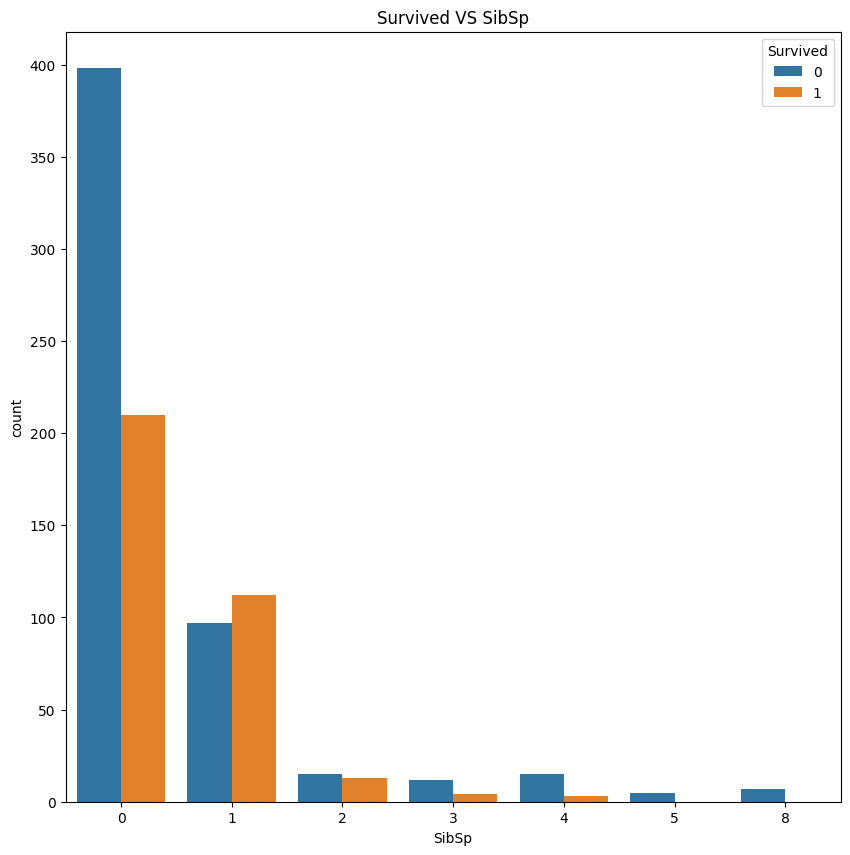

In [28]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "SibSp", hue = "Survived", data = tr)
plt.title("Survived VS SibSp")
plt.show()

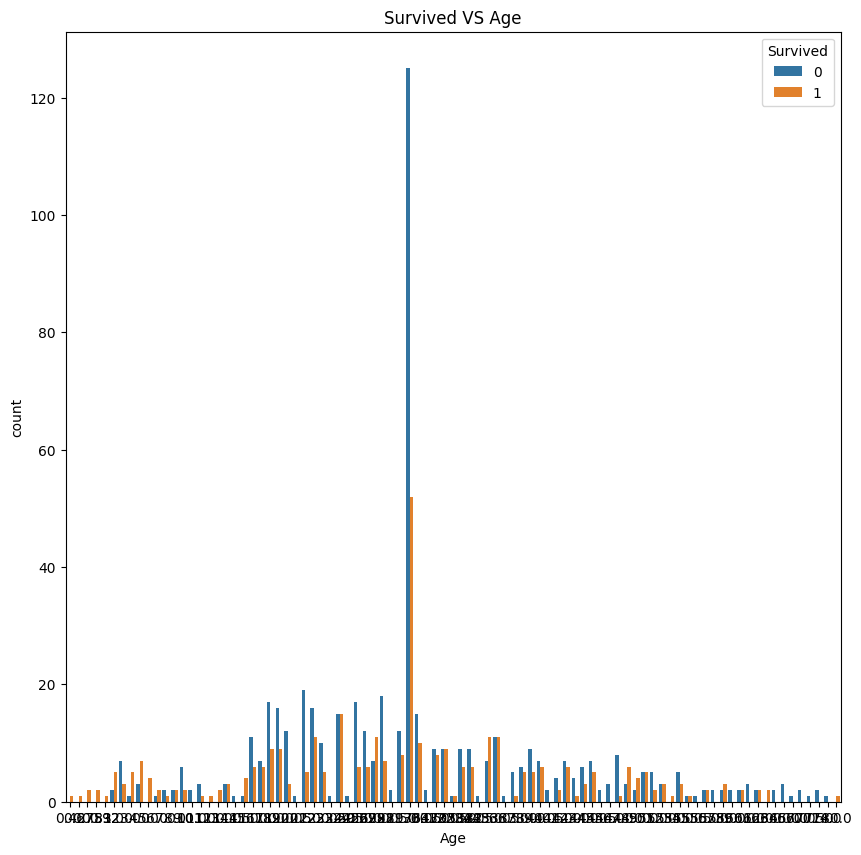

In [29]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "Age", hue = "Survived", data = tr)
plt.title("Survived VS Age")
plt.show()

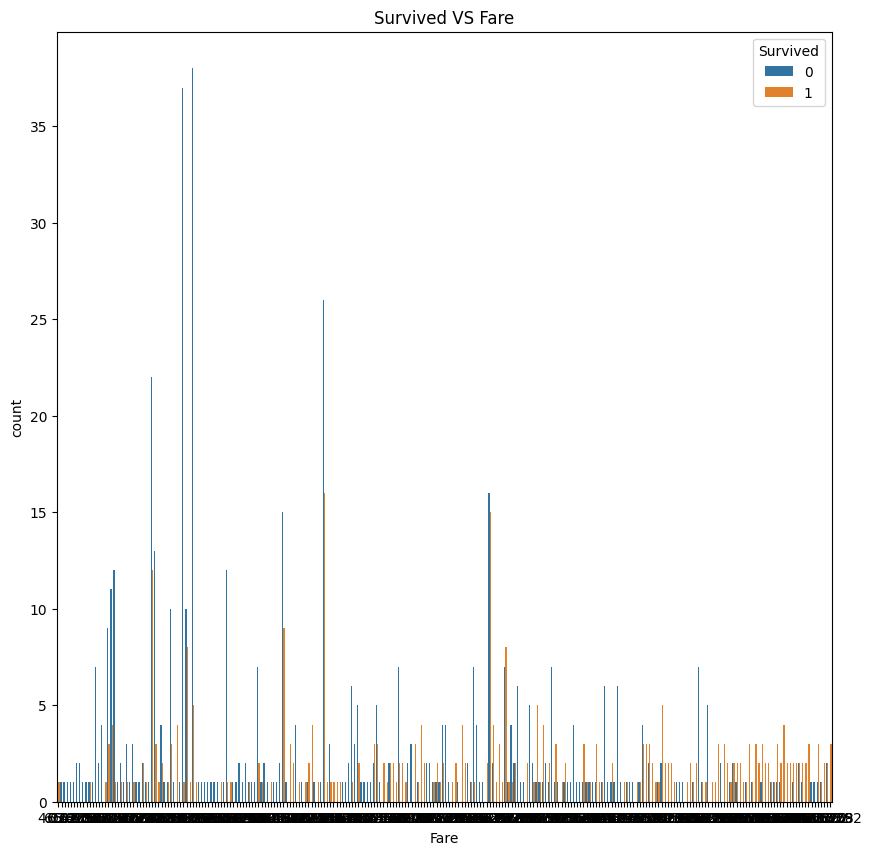

In [30]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "Fare", hue = "Survived", data = tr)
plt.title("Survived VS Fare")
plt.show()

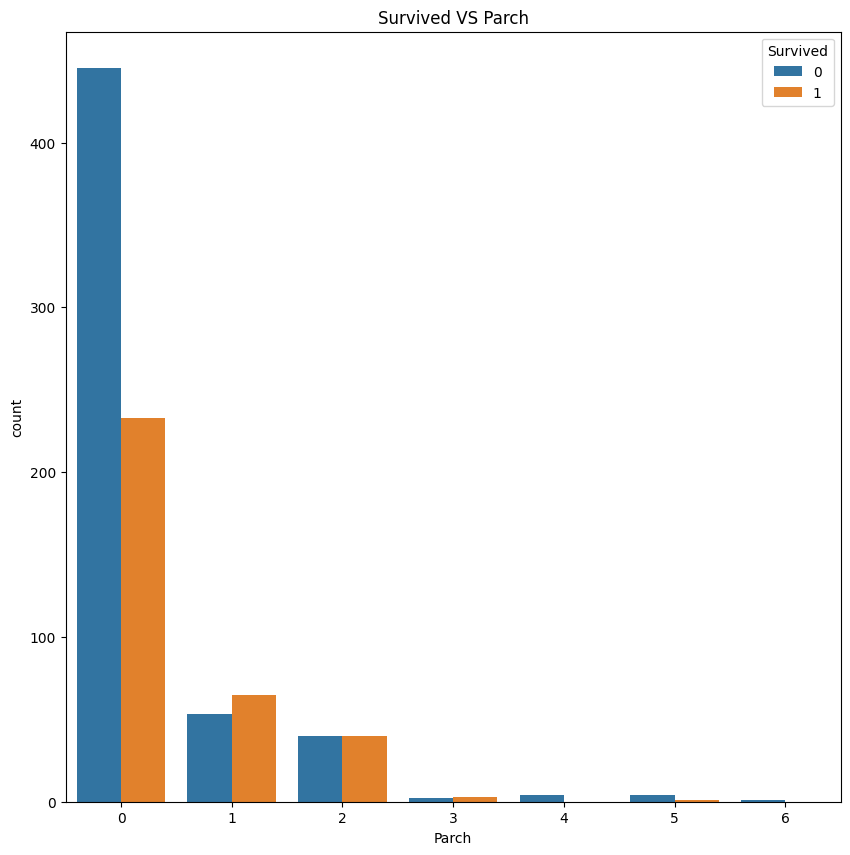

In [31]:
plt.figure(figsize = (10, 10))
sns.countplot(x = "Parch", hue = "Survived", data = tr)
plt.title("Survived VS Parch")
plt.show()

In [32]:
X=tr.drop(['Survived','Name','Ticket','Cabin','Embarked'], axis=1)
y=tr['Survived']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [34]:
decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X_train, y_train)
decision_tree_model.score(X_train, y_train)

1.0

In [35]:
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)
random_forest_model.score(X_train, y_train)

1.0

In [36]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)
NB_model.score(X_train, y_train)

0.7921348314606742

In [37]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)
knn_model.score(X_train, y_train)

0.7457865168539326

In [38]:
svmLinearModel=sklearn.svm.SVC(kernel='linear',C=10)
svmLinearModel.fit(X_train, y_train)
svmLinearModel.score(X_train, y_train)

0.7935393258426966

In [39]:
svmRbfModel=sklearn.svm.SVC(kernel='rbf',C=10)
svmRbfModel.fit(X_train, y_train)
svmRbfModel.score(X_train, y_train)

0.6797752808988764

In [40]:
svmPolyModel=sklearn.svm.SVC(kernel='poly',C=10000)
svmPolyModel.fit(X_train, y_train)
svmPolyModel.score(X_train, y_train)

0.7205056179775281

In [41]:
regressionModel = LogisticRegression(solver='liblinear')
regressionModel.fit(X_train, y_train)
regressionModel.score(X_train, y_train)

0.7949438202247191

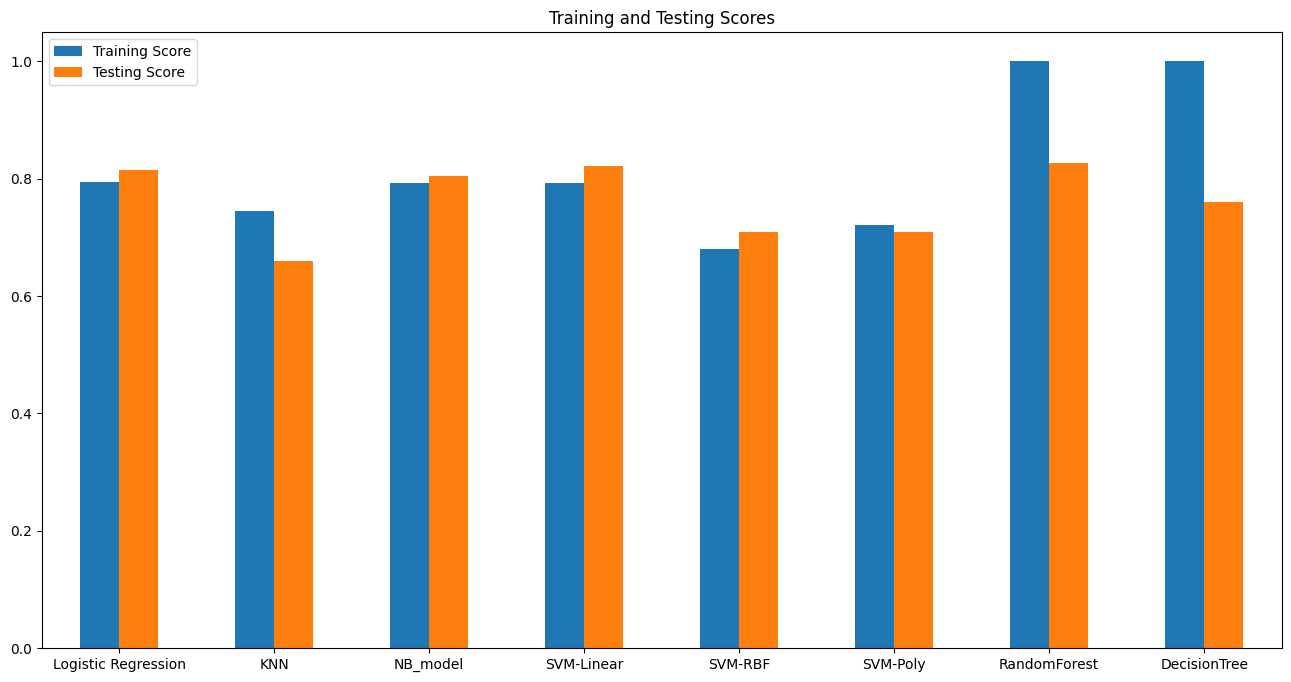

In [42]:
trainScores = [regressionModel.score(X_train, y_train), knn_model.score(X_train, y_train),NB_model.score(X_train, y_train), svmLinearModel.score(X_train, y_train), svmRbfModel.score(X_train, y_train),svmPolyModel.score(X_train, y_train),random_forest_model.score(X_train, y_train),decision_tree_model.score(X_train, y_train)]
testScores = [regressionModel.score(X_test, y_test), knn_model.score(X_test, y_test), NB_model.score(X_test, y_test),svmLinearModel.score(X_test, y_test), svmRbfModel.score(X_test, y_test),svmPolyModel.score(X_test, y_test),random_forest_model.score(X_test, y_test),decision_tree_model.score(X_test, y_test)]
indices = ['Logistic Regression', 'KNN','NB_model','SVM-Linear', 'SVM-RBF','SVM-Poly', 'RandomForest', 'DecisionTree']
scores = pd.DataFrame({'Training Score': trainScores,'Testing Score': testScores}, index=indices)
plot = scores.plot.bar(figsize=(16, 8), rot=0)
plt.title('Training and Testing Scores')
plt.show()

In [43]:
scores

,Training Score,Testing Score
Logistic Regression,0.794944,0.815642
KNN,0.745787,0.659218
NB_model,0.792135,0.804469
SVM-Linear,0.793539,0.821229
SVM-RBF,0.679775,0.709497
SVM-Poly,0.720506,0.709497
RandomForest,1.000000,0.826816
DecisionTree,1.000000,0.759777


In [44]:
predRegression = regressionModel.predict(X_test)
predSVMLinear = svmLinearModel.predict(X_test)
predSVMRbf = svmRbfModel.predict(X_test)
predKNN = knn_model.predict(X_test)
predSVMPoly = svmPolyModel.predict(X_test)
predRandomF = random_forest_model.predict(X_test)
predDTree = decision_tree_model.predict(X_test)
predNBC=NB_model.predict(X_test)
predVals = pd.DataFrame(data={'truth': y_test, 'regression': predRegression, 'knn': predKNN, 'svm-linear': predSVMLinear, 'svm-rbf': predSVMRbf, 'svm-poly': predSVMPoly, 'random-forest': predRandomF, 'decision-tree': predDTree,'Naive Bayes classifier':predNBC})

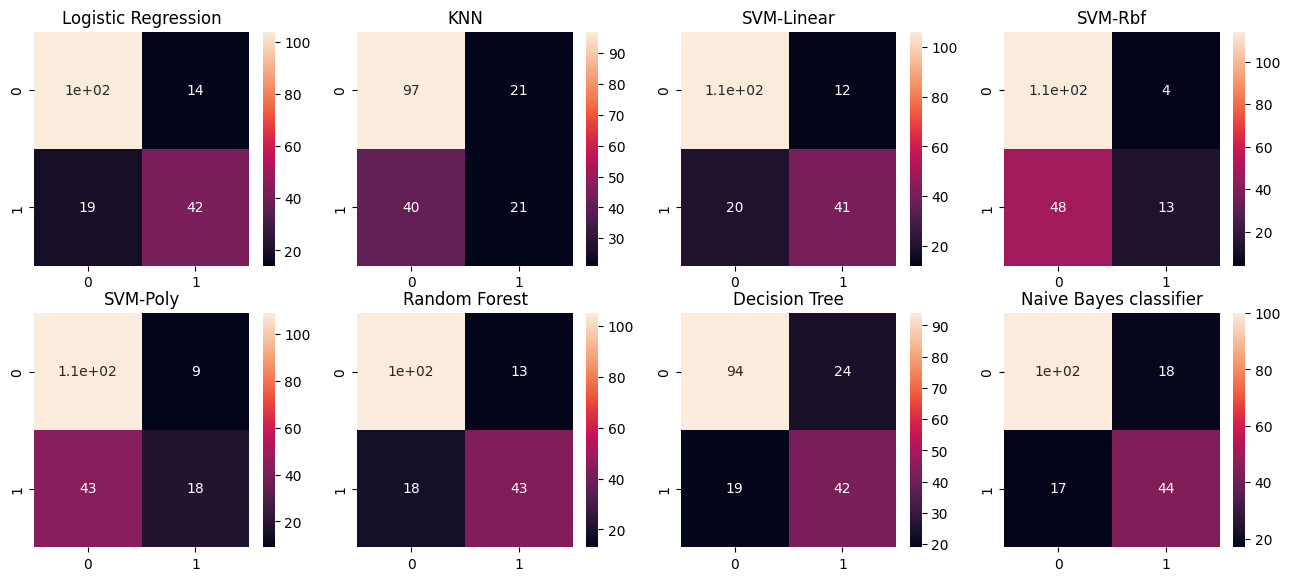

In [45]:
plt.figure(figsize=(16, 14))
plt.subplot(4, 4, 1)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predRegression), annot=True).set(title='Logistic Regression')
plt.subplot(4, 4, 2)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predKNN), annot=True).set(title='KNN')
plt.subplot(4, 4, 3)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predSVMLinear), annot=True).set(title='SVM-Linear')
plt.subplot(4, 4, 4)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predSVMRbf), annot=True).set(title='SVM-Rbf')
plt.subplot(4, 4, 5)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predSVMPoly), annot=True).set(title='SVM-Poly')
plt.subplot(4, 4, 6)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predRandomF), annot=True).set(title='Random Forest')
plt.subplot(4, 4, 7)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predDTree), annot=True).set(title='Decision Tree')
plt.subplot(4, 4, 8)
sns.heatmap(sklearn.metrics.confusion_matrix(y_test, predNBC), annot=True).set(title='Naive Bayes classifier')
plt.show()

In [46]:
print("Logistic Regression:\n\n", sklearn.metrics.classification_report(y_test, predRegression))

Logistic Regression:

               precision    recall  f1-score   support

           0       0.85      0.88      0.86       118
           1       0.75      0.69      0.72        61

    accuracy                           0.82       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.81      0.82      0.81       179



In [47]:
print("KNN:\n\n", sklearn.metrics.classification_report(y_test, predKNN))

KNN:

               precision    recall  f1-score   support

           0       0.71      0.82      0.76       118
           1       0.50      0.34      0.41        61

    accuracy                           0.66       179
   macro avg       0.60      0.58      0.58       179
weighted avg       0.64      0.66      0.64       179



In [48]:
print("SVM with linear kernel:\n\n", sklearn.metrics.classification_report(y_test, predSVMLinear))

SVM with linear kernel:

               precision    recall  f1-score   support

           0       0.84      0.90      0.87       118
           1       0.77      0.67      0.72        61

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.82      0.82      0.82       179



In [49]:
print("SVM with RBF kernel:\n\n", sklearn.metrics.classification_report(y_test, predSVMRbf))

SVM with RBF kernel:

               precision    recall  f1-score   support

           0       0.70      0.97      0.81       118
           1       0.76      0.21      0.33        61

    accuracy                           0.71       179
   macro avg       0.73      0.59      0.57       179
weighted avg       0.72      0.71      0.65       179



In [50]:
print("SVM with poly kernel:\n\n", sklearn.metrics.classification_report(y_test, predSVMPoly))

SVM with poly kernel:

               precision    recall  f1-score   support

           0       0.72      0.92      0.81       118
           1       0.67      0.30      0.41        61

    accuracy                           0.71       179
   macro avg       0.69      0.61      0.61       179
weighted avg       0.70      0.71      0.67       179



In [51]:
print("Random Forest:\n\n", sklearn.metrics.classification_report(y_test, predRandomF))

Random Forest:

               precision    recall  f1-score   support

           0       0.85      0.89      0.87       118
           1       0.77      0.70      0.74        61

    accuracy                           0.83       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.82      0.83      0.82       179



In [52]:
print("Decision Tree:\n\n", sklearn.metrics.classification_report(y_test, predDTree))

Decision Tree:

               precision    recall  f1-score   support

           0       0.83      0.80      0.81       118
           1       0.64      0.69      0.66        61

    accuracy                           0.76       179
   macro avg       0.73      0.74      0.74       179
weighted avg       0.77      0.76      0.76       179



In [53]:
print("Naive Bayes classifier:\n\n", sklearn.metrics.classification_report(y_test,predNBC))

Naive Bayes classifier:

               precision    recall  f1-score   support

           0       0.85      0.85      0.85       118
           1       0.71      0.72      0.72        61

    accuracy                           0.80       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.81      0.80      0.80       179



In [54]:
# Apply the same preprocessing steps to the test dataset 'te' as were applied to the training dataset 'tr'.

# Fill the one missing 'Fare' value in the test dataset with its mean.
te['Fare'] = te['Fare'].fillna(te['Fare'].mean())

# Convert 'Sex' column in the test dataset to numerical using the same dictionary.
# This step was applied to 'tr' in cell FxR-xgpz10cJ, but not to 'te'.
# The sexDict is available in the kernel state.
sexDict = {'male': 0, 'female': 1}
te.Sex = [sexDict[item] for item in te.Sex]

# Prepare the feature set for the test data (X_te) by dropping the non-feature columns,
# similar to how X was created from tr. Note that 'PassengerId' was included in X.
X_te = te.drop(['Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)

# Generate predictions for the actual test set using the best performing model (Random Forest).
predictions_on_test_data = random_forest_model.predict(X_te)

# Create the submission DataFrame.
submission = pd.DataFrame({'PassengerId': te['PassengerId'], 'Survived': predictions_on_test_data})
submission.to_csv('submission.csv', index = False)